In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# 1. 数据加载和预处理
data = pd.read_csv('life_expectancy_dataset.csv', sep=';', decimal=',')

data = data[['country_name', 'year', 'life_expectancy_women', 'life_expectancy_men']]
data['year'] = pd.to_datetime(data['year'], format='%Y')

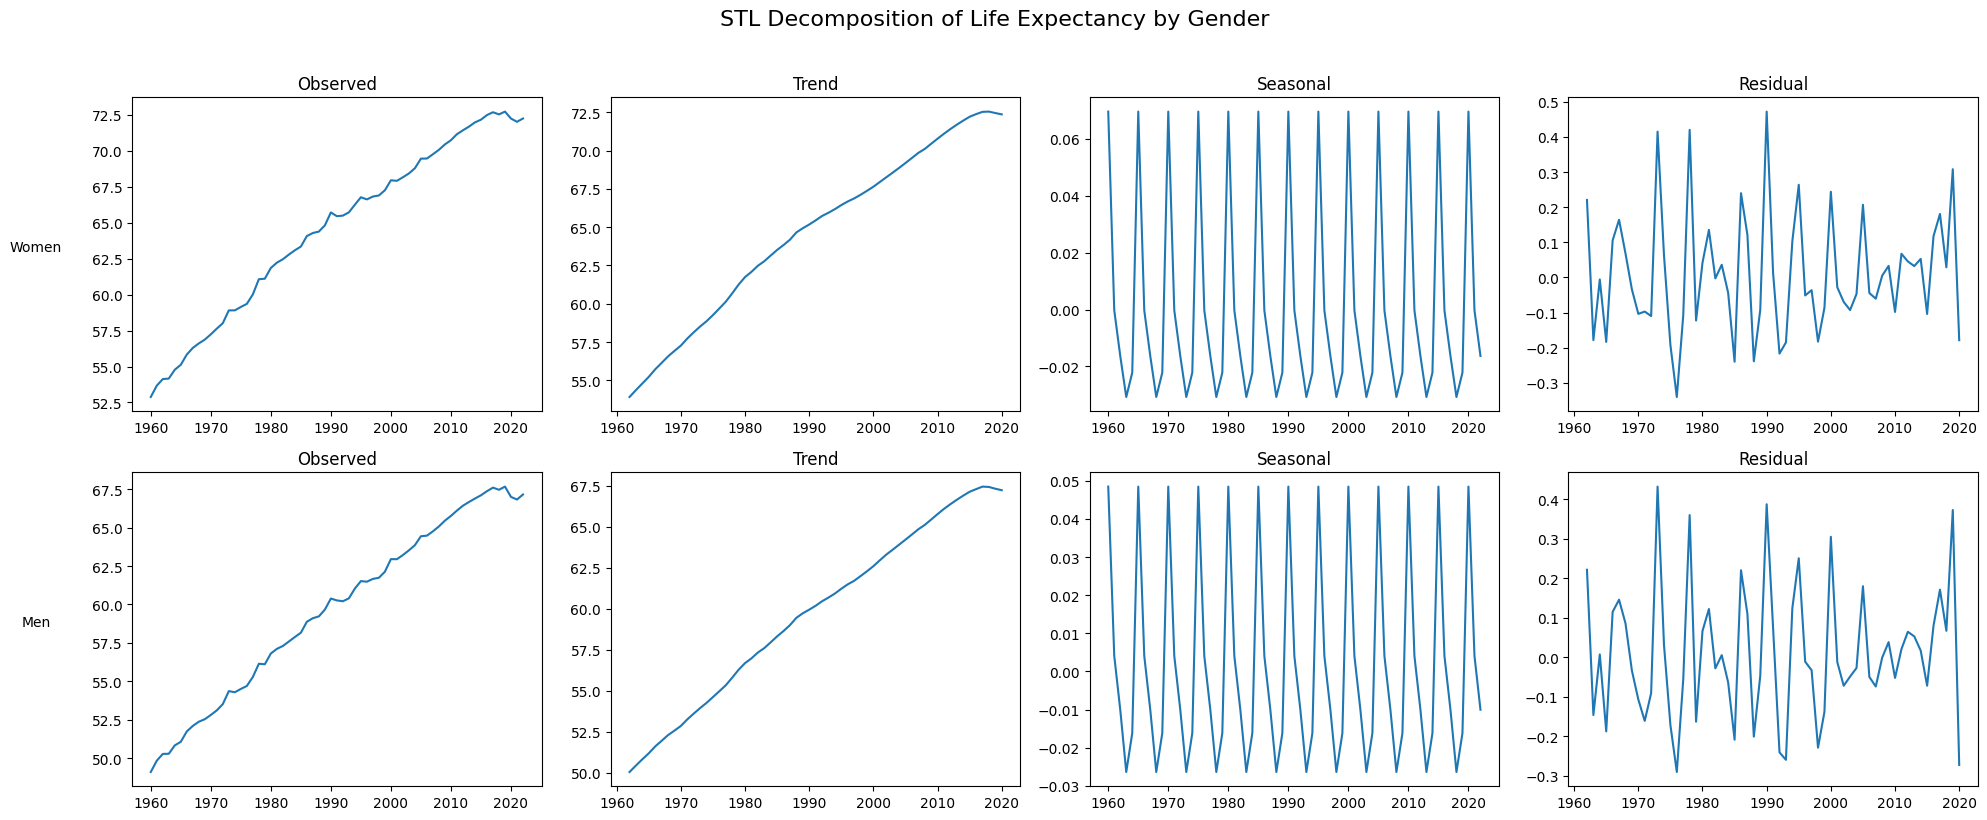

In [2]:
## ============ STL Decomposition: Plotting by Gender, with Each Gender Having a 4-Subplot (Observed/Trend/Seasonal/Residual) ============
genders = ['women', 'men']
fig, axes = plt.subplots(nrows=len(genders), ncols=4, 
                         figsize=(20, 4 * len(genders)), 
                         sharex=False)

for i, gender in enumerate(genders):
    df_grouped = data.groupby('year')[f'life_expectancy_{gender}'].mean()
    
    # window size = 5
    decomposition = seasonal_decompose(df_grouped, model='additive', period=5)
    
    # Observed / Trend / Seasonal / Resid
    axes[i, 0].plot(decomposition.observed)
    axes[i, 0].set_ylabel(gender.capitalize(), rotation=0, labelpad=40)
    axes[i, 0].set_title("Observed")

    axes[i, 1].plot(decomposition.trend)
    axes[i, 1].set_title("Trend")

    axes[i, 2].plot(decomposition.seasonal)
    axes[i, 2].set_title("Seasonal")

    axes[i, 3].plot(decomposition.resid)
    axes[i, 3].set_title("Residual")

plt.suptitle("STL Decomposition of Life Expectancy by Gender", y=1.02, fontsize=16)
plt.tight_layout()
plt.savefig("STL Decomposition of Life Expectancy by Gender.png", dpi=600)
plt.show()

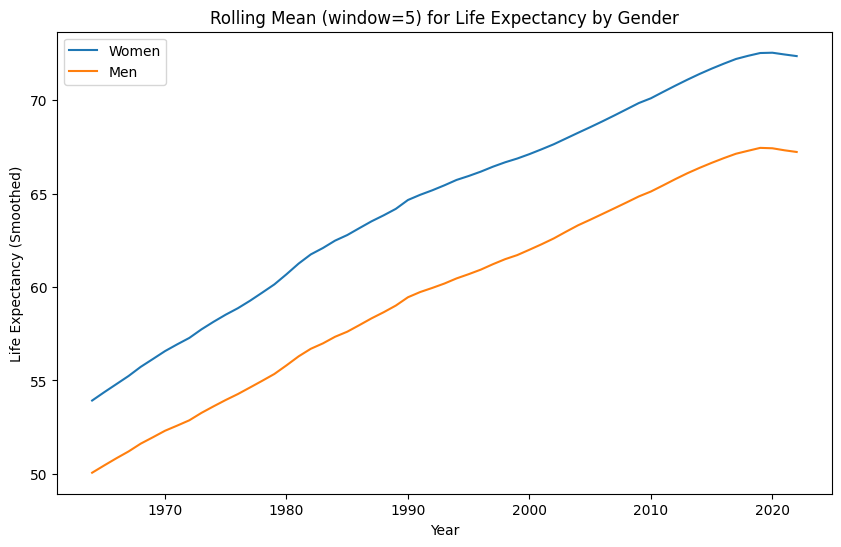

In [3]:
## ============ Moving Average Comparison: Multiple Lines in One Plot (By Gender) ============
window = 5  # Moving average window size
plt.figure(figsize=(10, 6))

for gender in genders:
    df_grouped = data.groupby('year')[f'life_expectancy_{gender}'].mean()
    rolling_mean = df_grouped.rolling(window=window).mean()
    plt.plot(rolling_mean.index, rolling_mean.values, label=gender.capitalize())

plt.title(f"Rolling Mean (window={window}) for Life Expectancy by Gender")
plt.xlabel("Year")
plt.ylabel("Life Expectancy (Smoothed)")
plt.legend()
plt.savefig("Rolling Mean (window={window}) for Life Expectancy by Gender.png", dpi=600)
plt.show()